In [58]:
import numpy as np
import pandas as pd
import os
import glob
from helper import get_data_splits, id_key, get_model
from define_model import create_MultiTaskTouchPoseNet

In [56]:
%load_ext autoreload
%autoreload 2

In [247]:
# Below identifiers correspond to evaluation protocol 1, 2 and 3 respectively
# identifiers - "TouchPose_crossSession", "TouchPose_crossSubjects", "TouchPose_crossGestures"
identifier = "TouchPose_crossGestures"
data_path = "../data/eth_data/"
model_path = "../models/"
new_data = "../data/27Arish"


In [248]:
files = glob.glob(data_path+'*.pkl')
df = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)

In [249]:
df.iloc[0]

cap_img       [[0, 1, -1, 0, 5, -4, -2, -1, 2, 3, 0, -2, -1,...
data_id                                                  3287.0
depth_img     [[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...
filename                              data_g_66_ 0_00003287.npz
gesture_id                                                 66.0
session_id                                         right_hand_1
subject_id                                                  P01
touch_id                                                    0.0
Name: 0, dtype: object

In [250]:
print(df.iloc[0].cap_img.shape)
print(df.iloc[0].depth_img.shape)

(41, 72)
(41, 72)


In [251]:
cap_img = pd.read_csv(new_data+"/Arish_1_UP_100_rawdata.csv",sep=' ')
display(cap_img)
#what is this exactly?
pen_img= pd.read_csv(new_data+"/Arish_1_UP_100_pendata.csv",sep=' ', header=None)
pen_img.head()

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,0,1,2,3,4,5,...,3014,3015,3016,3017,3018,3019,3020,3021,3022,3023
0,1680508053473,1680508053470,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1680508053489,1680508053485,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1680508053506,1680508053505,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1680508053519,1680508053515,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1680508053532,1680508053530,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6302,1680508137815,1680508137815,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6303,1680508137827,1680508137825,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6304,1680508137838,1680508137835,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6305,1680508137851,1680508137850,72,42,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,0,1,2,3,4,5,6,7,8,9,10
0,Arish1,4,100,1680508038535,1680508038535,2654,494,640,920,0,0
1,Arish1,4,100,1680508038540,1680508038540,2654,494,640,920,0,0
2,Arish1,4,100,1680508038545,1680508038545,2654,494,640,920,0,0
3,Arish1,4,100,1680508038551,1680508038550,2654,492,640,920,0,0
4,Arish1,4,100,1680508038557,1680508038555,2654,492,640,920,0,0


Concatenate the capacitive image cords

what is Merge Timestamps

In [252]:
pixels= cap_img.iloc[:, -3024:]
cap_img['img'] = pixels.values.tolist()
cap_img = cap_img.drop(pixels.columns, axis=1)
cap_img.head() 

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,img
0,1680508053473,1680508053470,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1680508053489,1680508053485,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,1680508053506,1680508053505,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1680508053519,1680508053515,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,1680508053532,1680508053530,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [253]:
pixels.iloc[:,1500].unique()

array([  0, 124, 176, 370, 364, 276, 334, 300, 378, 376, 308, 264, 198,
       232, 252, 180, 288, 286, 360, 342, 374, 362, 422, 266, 282, 280,
       310, 358, 322, 386, 368, 406, 302, 150,  50,  40,  72,  86, 332,
       438, 442, 680, 590, 652, 616, 694, 656, 678, 606, 558, 672, 522,
       458, 550, 546, 480, 412, 496, 278,  98,  68,  84, 126,  46,  48,
         6,  20, 494, 596, 366, 182, 340, 488, 538, 474, 524, 594, 470,
       544, 602, 608, 588, 600, 526, 586, 640, 568, 638, 804, 684, 646,
       628, 578, 554, 502, 630, 580, 520, 574, 566, 556, 598, 654, 482,
       610, 604, 452, 576, 552, 614, 518, 506, 414, 430, 248, 250,  80,
        18,   4, 118, 296, 256, 172, 344, 162, 214, 230,  90, 258, 216,
       292], dtype=int64)

In [12]:
#no length problem
cap_img[cap_img['img'].apply(lambda x: len(x)) != 3024]

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,img


<Axes: xlabel='img', ylabel='Count'>

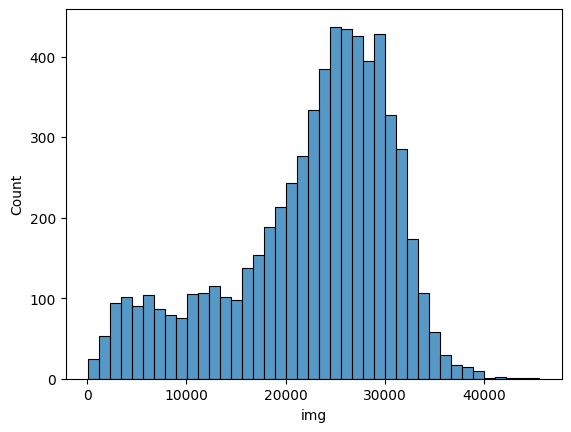

In [13]:
import seaborn as sns

sns.histplot(cap_img['img'].apply(lambda x:sum(x)))


In [14]:
valid_wacom= pd.read_csv(new_data+"/userarish_2023-04-03_10-09-56_43452_videoframe.csv",sep=',', index_col=0)
display(valid_wacom)
skeleton= pd.read_csv(new_data+"/userarish_2023-04-03_10-10-07_11956_handleap.csv",sep=',', index_col=0)
skeleton.head()

,time,valid_hand
0,1.680508e+09,0
1,1.680508e+09,0
2,1.680508e+09,0
3,1.680508e+09,0
4,1.680508e+09,0
...,...,...
43447,1.680509e+09,0
43448,1.680509e+09,0
43449,1.680509e+09,0
43450,1.680509e+09,0


,Timestamp,wrist_x,wrist_y,wrist_z,Thumb_0_x,Thumb_0_y,Thumb_0_z,Thumb_1_x,Thumb_1_y,Thumb_1_z,...,Pinky_1_z,Pinky_2_x,Pinky_2_y,Pinky_2_z,Pinky_3_x,Pinky_3_y,Pinky_3_z,Pinky_4_x,Pinky_4_y,Pinky_4_z
0,1.680508e+09,-139.203323,274.228577,49.082916,-114.933983,253.419250,30.097525,-114.933983,253.419250,30.097525,...,-1.378431,-79.235779,316.579315,-9.686751,-66.095505,310.570587,-4.683544,-63.091114,302.499756,3.833986
1,1.680508e+09,-140.807953,275.914978,48.604588,-116.763191,254.998688,29.973202,-116.763191,254.998688,29.973202,...,-1.610328,-81.087822,317.742035,-10.036551,-67.429924,312.277679,-5.582808,-63.150959,305.029114,2.546285
2,1.680508e+09,-141.657455,276.928864,48.438431,-117.944008,255.992447,29.780630,-117.944008,255.992447,29.780630,...,-1.542735,-82.366440,318.522095,-10.068500,-68.662849,313.191895,-6.016860,-64.336670,305.981537,1.776773
3,1.680508e+09,-142.424988,277.627655,48.370846,-118.904243,256.690155,29.705805,-118.904243,256.690155,29.705805,...,-1.483135,-83.491470,319.006104,-10.107798,-69.866707,313.695801,-6.286170,-65.547409,306.522583,1.397558
4,1.680508e+09,-143.209824,278.107635,48.447624,-119.784531,257.230042,29.819784,-119.784531,257.230042,29.819784,...,-1.366892,-84.573372,319.315247,-10.042198,-71.030754,313.933380,-6.230742,-66.825378,306.697205,1.491625


valid_hand no true values

In [15]:
valid_wacom.valid_hand.any()

False

Image in report with 25 locations, each finger has 5 positions

In [41]:
skeleton.columns

Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Thumb_4_x', 'Thumb_4_y', 'Thumb_4_z', 'Index_0_x', 'Index_0_y',
       'Index_0_z', 'Index_1_x', 'Index_1_y', 'Index_1_z', 'Index_2_x',
       'Index_2_y', 'Index_2_z', 'Index_3_x', 'Index_3_y', 'Index_3_z',
       'Index_4_x', 'Index_4_y', 'Index_4_z', 'Middle_0_x', 'Middle_0_y',
       'Middle_0_z', 'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x',
       'Middle_2_y', 'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z',
       'Middle_4_x', 'Middle_4_y', 'Middle_4_z', 'Ring_0_x', 'Ring_0_y',
       'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x', 'Ring_2_y',
       'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Ring_4_x', 'Ring_4_y',
       'Ring_4_z', 'Pinky_0_x', 'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x',
       'Pinky_1_y', 'Pinky_1_z'

In [17]:
len(skeleton.columns)

79

In [18]:
valid_ipad= pd.read_csv(new_data+"/userarish_ipad_2023-04-03_10-13-28_49778_videoframe.csv",sep=',',usecols=[1,2])
valid_ipad.head()

,time,valid_hand
0,1.680508e+09,0
1,1.680508e+09,0
2,1.680508e+09,0
3,1.680508e+09,0
4,1.680508e+09,0


same problem for ipad

In [19]:
valid_ipad.valid_hand.any()

False

Trying to run the model

In [20]:
control = id_key[identifier]
df_group = df.groupby([control])[["cap_img","depth_img"]]
g_id = list(df_group.groups.keys())

In [21]:
depth_err = []
for i in range(len(g_id)):
    test_set = [g_id[i]]
    X_test_cap, Y_test_depth= get_data_splits(df_group,test_set)
    model = get_model(identifier, model_path, test_set)
    Y_out_depth = model.predict(X_test_cap, batch_size=128)
    depth_error = np.mean(abs(Y_test_depth - Y_out_depth[:,:,:,0])) * 255
    depth_err.append(depth_error)
    print("Accuracy", g_id[i],depth_error)
    break


42/42 [==============================] - 5s 61ms/step
Accuracy 65.0 30.418464906828085


In [22]:
X_test_cap.shape

(5275, 41, 72)

In [33]:
input=np.array(cap_img['img'].map(lambda x: np.array(x).reshape(42,72)).tolist())
print(input.shape)
input=input[:,:41,:]
print(input.shape)

(6307, 42, 72)
(6307, 41, 72)


In [34]:
maxVal = 0
minval = 100000
for i in range(len(input)):
    if maxVal < np.max(input[i]):
        maxVal = np.max(input[i])
    if minval > np.min(input[i]):
        minval = np.min(input[i])
print(maxVal)
print(minval)

1501
0


In [35]:
imput = input/maxVal

In [38]:
Y_out_depth=model.predict(imput, batch_size=128)

50/50 [==============================] - 3s 51ms/step


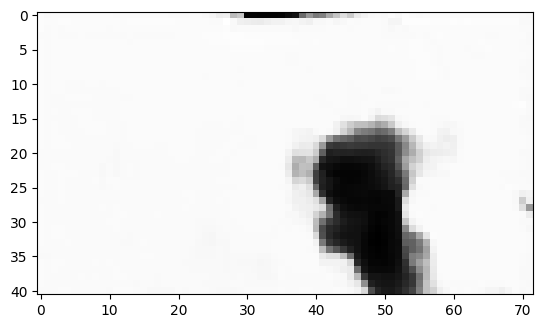

In [39]:
import matplotlib.pyplot as plt

plt.imshow(Y_out_depth[5000], cmap='gray')

In [40]:
skeleton.shape

(11956, 79)

Skeleton data

In [48]:
skeleton.head()

,Timestamp,wrist_x,wrist_y,wrist_z,Thumb_0_x,Thumb_0_y,Thumb_0_z,Thumb_1_x,Thumb_1_y,Thumb_1_z,...,Pinky_1_z,Pinky_2_x,Pinky_2_y,Pinky_2_z,Pinky_3_x,Pinky_3_y,Pinky_3_z,Pinky_4_x,Pinky_4_y,Pinky_4_z
0,1.680508e+09,-139.203323,274.228577,49.082916,-114.933983,253.419250,30.097525,-114.933983,253.419250,30.097525,...,-1.378431,-79.235779,316.579315,-9.686751,-66.095505,310.570587,-4.683544,-63.091114,302.499756,3.833986
1,1.680508e+09,-140.807953,275.914978,48.604588,-116.763191,254.998688,29.973202,-116.763191,254.998688,29.973202,...,-1.610328,-81.087822,317.742035,-10.036551,-67.429924,312.277679,-5.582808,-63.150959,305.029114,2.546285
2,1.680508e+09,-141.657455,276.928864,48.438431,-117.944008,255.992447,29.780630,-117.944008,255.992447,29.780630,...,-1.542735,-82.366440,318.522095,-10.068500,-68.662849,313.191895,-6.016860,-64.336670,305.981537,1.776773
3,1.680508e+09,-142.424988,277.627655,48.370846,-118.904243,256.690155,29.705805,-118.904243,256.690155,29.705805,...,-1.483135,-83.491470,319.006104,-10.107798,-69.866707,313.695801,-6.286170,-65.547409,306.522583,1.397558
4,1.680508e+09,-143.209824,278.107635,48.447624,-119.784531,257.230042,29.819784,-119.784531,257.230042,29.819784,...,-1.366892,-84.573372,319.315247,-10.042198,-71.030754,313.933380,-6.230742,-66.825378,306.697205,1.491625


In [49]:
skeleton.columns

Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Thumb_4_x', 'Thumb_4_y', 'Thumb_4_z', 'Index_0_x', 'Index_0_y',
       'Index_0_z', 'Index_1_x', 'Index_1_y', 'Index_1_z', 'Index_2_x',
       'Index_2_y', 'Index_2_z', 'Index_3_x', 'Index_3_y', 'Index_3_z',
       'Index_4_x', 'Index_4_y', 'Index_4_z', 'Middle_0_x', 'Middle_0_y',
       'Middle_0_z', 'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x',
       'Middle_2_y', 'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z',
       'Middle_4_x', 'Middle_4_y', 'Middle_4_z', 'Ring_0_x', 'Ring_0_y',
       'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x', 'Ring_2_y',
       'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Ring_4_x', 'Ring_4_y',
       'Ring_4_z', 'Pinky_0_x', 'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x',
       'Pinky_1_y', 'Pinky_1_z'

In [47]:
skeleton.Timestamp.is_unique

True

Load the model for skeleton prediction

In [52]:
model.layers

In [84]:
print(len(multi_task_model.layers))
print(len(model.layers))

34
26


In [ ]:
multi_task_model = create_MultiTaskTouchPoseNet(41, 72, 1)

In [128]:
from itertools import zip_longest
match = []
for depth_layer, multi_layer, matching in zip_longest(model.layers,multi_task_model.layers,range(len(multi_task_model.layers)),fillvalue='0'):
        if(depth_layer!='0'):
            match.append((depth_layer.name, multi_layer.name, (matching,matching)))
        else : 
            match.append((depth_layer, multi_layer.name,(matching,matching)))
match

[('input_25', 'input_21', (0, 0)),
 ('conv2d_336', 'conv2d_280', (1, 1)),
 ('conv2d_337', 'conv2d_281', (2, 2)),
 ('max_pooling2d_72', 'max_pooling2d_60', (3, 3)),
 ('conv2d_338', 'conv2d_282', (4, 4)),
 ('conv2d_339', 'conv2d_283', (5, 5)),
 ('max_pooling2d_73', 'max_pooling2d_61', (6, 6)),
 ('conv2d_340', 'conv2d_284', (7, 7)),
 ('conv2d_341', 'conv2d_285', (8, 8)),
 ('max_pooling2d_74', 'max_pooling2d_62', (9, 9)),
 ('conv2d_342', 'conv2d_286', (10, 10)),
 ('conv2d_343', 'conv2d_287', (11, 11)),
 ('up_sampling2d_72', 'up_sampling2d_60', (12, 12)),
 ('concatenate_72', 'concatenate_60', (13, 13)),
 ('conv2d_344', 'conv2d_288', (14, 14)),
 ('conv2d_345', 'conv2d_289', (15, 15)),
 ('up_sampling2d_73', 'up_sampling2d_61', (16, 16)),
 ('concatenate_73', 'concatenate_61', (17, 17)),
 ('conv2d_346', 'conv2d_290', (18, 18)),
 ('conv2d_347', 'flatten_20', (19, 19)),
 ('up_sampling2d_74', 'conv2d_291', (20, 20)),
 ('tf.compat.v1.pad_24', 'dense_40', (21, 21)),
 ('concatenate_74', 'up_sampling2

In [151]:
match = [ (''.join([ xi for xi in x[0] if not xi.isdigit()]),''.join([ xi for xi in x[1] if not xi.isdigit()]), x[2]) for x in match]
bad_match = [x for x in match if x[0]!=x[1]]
bad_match

[('convd_', 'flatten_', (19, 19)),
 ('up_samplingd_', 'convd_', (20, 20)),
 ('tf.compat.v.pad_', 'dense_', (21, 21)),
 ('concatenate_', 'up_samplingd_', (22, 22)),
 ('convd_', 'activation_', (23, 23)),
 ('convd_', 'tf.compat.v.pad_', (24, 24)),
 ('regression_depth', 'batch_normalization_', (25, 25)),
 ('', 'concatenate_', (26, 26)),
 ('', 'dropout_', (27, 27)),
 ('', 'convd_', (28, 28)),
 ('', 'dense_', (29, 29)),
 ('', 'convd_', (30, 30)),
 ('', 'regression', (31, 31)),
 ('', 'visibility', (32, 32)),
 ('', 'regression_depth', (33, 33))]

In [152]:
bad_match_sec = bad_match.copy()

for i in range(len(bad_match)):
    for j in range(len(bad_match_sec)):
        if bad_match[i][0]==bad_match_sec[j][1]:
            new_match = list(bad_match[i])
            new_match[1] = bad_match_sec[j][1]
            new_match[2] = (bad_match[i][2][0],bad_match_sec[j][2][1])
            bad_match[i] = tuple(new_match)
            bad_match_sec.remove(bad_match_sec[j])
            break

bad_match

[('convd_', 'convd_', (19, 20)),
 ('up_samplingd_', 'up_samplingd_', (20, 22)),
 ('tf.compat.v.pad_', 'tf.compat.v.pad_', (21, 24)),
 ('concatenate_', 'concatenate_', (22, 26)),
 ('convd_', 'convd_', (23, 28)),
 ('convd_', 'convd_', (24, 30)),
 ('regression_depth', 'regression_depth', (25, 33)),
 ('', 'concatenate_', (26, 26)),
 ('', 'dropout_', (27, 27)),
 ('', 'convd_', (28, 28)),
 ('', 'dense_', (29, 29)),
 ('', 'convd_', (30, 30)),
 ('', 'regression', (31, 31)),
 ('', 'visibility', (32, 32)),
 ('', 'regression_depth', (33, 33))]

In [156]:
good_match = [x for x in match if x[0]==x[1]]
match = [x for x in good_match + bad_match if x[0]==x[1]]
match

[('input_', 'input_', (0, 0)),
 ('convd_', 'convd_', (1, 1)),
 ('convd_', 'convd_', (2, 2)),
 ('max_poolingd_', 'max_poolingd_', (3, 3)),
 ('convd_', 'convd_', (4, 4)),
 ('convd_', 'convd_', (5, 5)),
 ('max_poolingd_', 'max_poolingd_', (6, 6)),
 ('convd_', 'convd_', (7, 7)),
 ('convd_', 'convd_', (8, 8)),
 ('max_poolingd_', 'max_poolingd_', (9, 9)),
 ('convd_', 'convd_', (10, 10)),
 ('convd_', 'convd_', (11, 11)),
 ('up_samplingd_', 'up_samplingd_', (12, 12)),
 ('concatenate_', 'concatenate_', (13, 13)),
 ('convd_', 'convd_', (14, 14)),
 ('convd_', 'convd_', (15, 15)),
 ('up_samplingd_', 'up_samplingd_', (16, 16)),
 ('concatenate_', 'concatenate_', (17, 17)),
 ('convd_', 'convd_', (18, 18)),
 ('convd_', 'convd_', (19, 20)),
 ('up_samplingd_', 'up_samplingd_', (20, 22)),
 ('tf.compat.v.pad_', 'tf.compat.v.pad_', (21, 24)),
 ('concatenate_', 'concatenate_', (22, 26)),
 ('convd_', 'convd_', (23, 28)),
 ('convd_', 'convd_', (24, 30)),
 ('regression_depth', 'regression_depth', (25, 33)),
 (

Best matching done, now assign weights

In [157]:
for i in range(len(model.layers)):
    d = good_match[i][2][0]
    m = good_match[i][2][1]
    multi_task_model.layers[m].set_weights(model.layers[d].get_weights())

Model is partially ready

In [163]:
multi_task_model.output

[<KerasTensor: shape=(None, 63) dtype=float32 (created by layer 'regression')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'visibility')>,
 <KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'regression_depth')>]

In [164]:
multi_task_model.input

<KerasTensor: shape=(None, 41, 72, 1) dtype=float32 (created by layer 'input_21')>

In [204]:
ys=multi_task_model.predict(imput, batch_size=128)

50/50 [==============================] - 2s 50ms/step


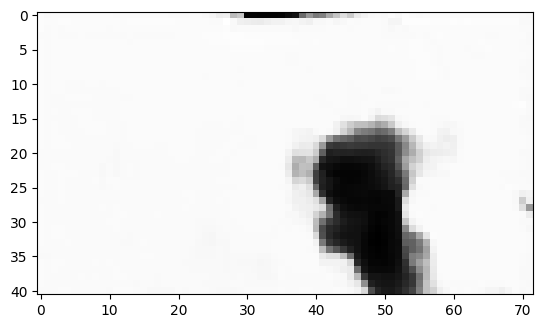

In [211]:
import matplotlib.pyplot as plt

plt.imshow(ys[2][5000], cmap='gray')

same as before

In [221]:
ys[0][5000]

array([ -5.746292 ,  -0.8452449,  40.311398 ,  15.5062475,   9.973003 ,
        32.773254 , -31.39932  ,  61.91788  ,  21.316334 ,  -3.338256 ,
        37.525803 ,  -6.5401697,  -2.7277603,  29.131186 ,   9.9569435,
         6.6763144,  69.010376 , -45.229057 ,  17.128555 , -23.237047 ,
        -6.113634 ,  12.482658 ,  18.22353  ,  -1.4669724, -36.288017 ,
        24.708952 , -16.270187 ,  -9.736454 , -10.095505 ,   5.6280727,
        20.959108 , -18.526276 , -26.861963 , -17.652353 , -34.464855 ,
         7.613735 , -15.12686  , -10.844618 , -43.7956   ,  -6.1983557,
        12.550306 , -19.157116 ,  -3.6025314,  -8.350088 ,  -2.7356691,
        48.205273 ,  24.668032 ,  39.88264  , -19.27085  , -19.363838 ,
       -38.350956 , -28.351772 ,  29.989841 ,  19.758533 , -18.936304 ,
        10.73542  ,  34.382576 , -56.517517 , -31.521011 , -11.864273 ,
        17.163364 , -29.705269 ,  38.778435 ], dtype=float32)

In [224]:
skeleton.columns

Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Thumb_4_x', 'Thumb_4_y', 'Thumb_4_z', 'Index_0_x', 'Index_0_y',
       'Index_0_z', 'Index_1_x', 'Index_1_y', 'Index_1_z', 'Index_2_x',
       'Index_2_y', 'Index_2_z', 'Index_3_x', 'Index_3_y', 'Index_3_z',
       'Index_4_x', 'Index_4_y', 'Index_4_z', 'Middle_0_x', 'Middle_0_y',
       'Middle_0_z', 'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x',
       'Middle_2_y', 'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z',
       'Middle_4_x', 'Middle_4_y', 'Middle_4_z', 'Ring_0_x', 'Ring_0_y',
       'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x', 'Ring_2_y',
       'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Ring_4_x', 'Ring_4_y',
       'Ring_4_z', 'Pinky_0_x', 'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x',
       'Pinky_1_y', 'Pinky_1_z'

In [255]:
s=skeleton.copy()
#s=s.drop(['Timestamp'],axis=1)
for x in ['Thumb','Index','Middle','Ring','Pinky'] :
    s=s.drop([f'{x}_4_x', f'{x}_4_y', f'{x}_4_z'],axis=1)
s.columns

Index(['Timestamp', 'wrist_x', 'wrist_y', 'wrist_z', 'Thumb_0_x', 'Thumb_0_y',
       'Thumb_0_z', 'Thumb_1_x', 'Thumb_1_y', 'Thumb_1_z', 'Thumb_2_x',
       'Thumb_2_y', 'Thumb_2_z', 'Thumb_3_x', 'Thumb_3_y', 'Thumb_3_z',
       'Index_0_x', 'Index_0_y', 'Index_0_z', 'Index_1_x', 'Index_1_y',
       'Index_1_z', 'Index_2_x', 'Index_2_y', 'Index_2_z', 'Index_3_x',
       'Index_3_y', 'Index_3_z', 'Middle_0_x', 'Middle_0_y', 'Middle_0_z',
       'Middle_1_x', 'Middle_1_y', 'Middle_1_z', 'Middle_2_x', 'Middle_2_y',
       'Middle_2_z', 'Middle_3_x', 'Middle_3_y', 'Middle_3_z', 'Ring_0_x',
       'Ring_0_y', 'Ring_0_z', 'Ring_1_x', 'Ring_1_y', 'Ring_1_z', 'Ring_2_x',
       'Ring_2_y', 'Ring_2_z', 'Ring_3_x', 'Ring_3_y', 'Ring_3_z', 'Pinky_0_x',
       'Pinky_0_y', 'Pinky_0_z', 'Pinky_1_x', 'Pinky_1_y', 'Pinky_1_z',
       'Pinky_2_x', 'Pinky_2_y', 'Pinky_2_z', 'Pinky_3_x', 'Pinky_3_y',
       'Pinky_3_z'],
      dtype='object')

In [256]:
s.head()

,Timestamp,wrist_x,wrist_y,wrist_z,Thumb_0_x,Thumb_0_y,Thumb_0_z,Thumb_1_x,Thumb_1_y,Thumb_1_z,...,Pinky_0_z,Pinky_1_x,Pinky_1_y,Pinky_1_z,Pinky_2_x,Pinky_2_y,Pinky_2_z,Pinky_3_x,Pinky_3_y,Pinky_3_z
0,1.680508e+09,-139.203323,274.228577,49.082916,-114.933983,253.419250,30.097525,-114.933983,253.419250,30.097525,...,30.810373,-101.600784,312.727509,-1.378431,-79.235779,316.579315,-9.686751,-66.095505,310.570587,-4.683544
1,1.680508e+09,-140.807953,275.914978,48.604588,-116.763191,254.998688,29.973202,-116.763191,254.998688,29.973202,...,30.456799,-103.461205,313.773743,-1.610328,-81.087822,317.742035,-10.036551,-67.429924,312.277679,-5.582808
2,1.680508e+09,-141.657455,276.928864,48.438431,-117.944008,255.992447,29.780630,-117.944008,255.992447,29.780630,...,30.409733,-104.594521,314.625885,-1.542735,-82.366440,318.522095,-10.068500,-68.662849,313.191895,-6.016860
3,1.680508e+09,-142.424988,277.627655,48.370846,-118.904243,256.690155,29.705805,-118.904243,256.690155,29.705805,...,30.407902,-105.538300,315.195709,-1.483135,-83.491470,319.006104,-10.107798,-69.866707,313.695801,-6.286170
4,1.680508e+09,-143.209824,278.107635,48.447624,-119.784531,257.230042,29.819784,-119.784531,257.230042,29.819784,...,30.510523,-106.508232,315.579651,-1.366892,-84.573372,319.315247,-10.042198,-71.030754,313.933380,-6.230742


In [261]:
s.Timestamp=s.Timestamp.astype('int64')
s

,Timestamp,wrist_x,wrist_y,wrist_z,Thumb_0_x,Thumb_0_y,Thumb_0_z,Thumb_1_x,Thumb_1_y,Thumb_1_z,...,Pinky_0_z,Pinky_1_x,Pinky_1_y,Pinky_1_z,Pinky_2_x,Pinky_2_y,Pinky_2_z,Pinky_3_x,Pinky_3_y,Pinky_3_z
0,1680508023,-139.203323,274.228577,49.082916,-114.933983,253.419250,30.097525,-114.933983,253.419250,30.097525,...,30.810373,-101.600784,312.727509,-1.378431,-79.235779,316.579315,-9.686751,-66.095505,310.570587,-4.683544
1,1680508023,-140.807953,275.914978,48.604588,-116.763191,254.998688,29.973202,-116.763191,254.998688,29.973202,...,30.456799,-103.461205,313.773743,-1.610328,-81.087822,317.742035,-10.036551,-67.429924,312.277679,-5.582808
2,1680508023,-141.657455,276.928864,48.438431,-117.944008,255.992447,29.780630,-117.944008,255.992447,29.780630,...,30.409733,-104.594521,314.625885,-1.542735,-82.366440,318.522095,-10.068500,-68.662849,313.191895,-6.016860
3,1680508023,-142.424988,277.627655,48.370846,-118.904243,256.690155,29.705805,-118.904243,256.690155,29.705805,...,30.407902,-105.538300,315.195709,-1.483135,-83.491470,319.006104,-10.107798,-69.866707,313.695801,-6.286170
4,1680508023,-143.209824,278.107635,48.447624,-119.784531,257.230042,29.819784,-119.784531,257.230042,29.819784,...,30.510523,-106.508232,315.579651,-1.366892,-84.573372,319.315247,-10.042198,-71.030754,313.933380,-6.230742
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11951,1680509386,-287.545502,242.204926,142.150970,-277.866547,219.380219,114.335548,-277.866547,219.380219,114.335548,...,122.771072,-319.952271,243.906540,84.416809,-316.342743,243.100098,61.508736,-304.145447,243.080399,55.580845
11952,1680509386,-296.408905,245.931625,150.882568,-286.497070,224.579926,122.109245,-286.497070,224.579926,122.109245,...,131.596283,-328.455933,249.770615,92.883324,-324.873596,249.959091,69.932190,-312.863922,250.377182,63.832031
11953,1680509386,-299.915009,242.820190,155.914261,-290.749023,220.851974,126.905380,-290.749023,220.851974,126.905380,...,136.825684,-331.395264,243.786057,97.387924,-327.821960,244.267105,74.590218,-316.270813,244.602737,69.625198
11954,1680509386,-302.475250,244.527496,158.779510,-293.015594,223.080750,130.616714,-293.015594,223.080750,130.616714,...,138.952835,-332.883759,249.868118,99.326805,-328.745697,250.244614,76.611877,-316.968933,250.163528,71.764153


In [ ]:
1680508137862
   1680509386
np.dicretize(s.Timestamp, bins=10)

In [262]:
cap_img

,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,img
0,1680508053473,1680508053470,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1680508053489,1680508053485,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,1680508053506,1680508053505,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,1680508053519,1680508053515,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,1680508053532,1680508053530,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
6302,1680508137815,1680508137815,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6303,1680508137827,1680508137825,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6304,1680508137838,1680508137835,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6305,1680508137851,1680508137850,72,42,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [260]:
pd.merge(s,cap_img,how='inner',left_on='Timestamp',right_on='TimeStamps')

,Timestamp,wrist_x,wrist_y,wrist_z,Thumb_0_x,Thumb_0_y,Thumb_0_z,Thumb_1_x,Thumb_1_y,Thumb_1_z,...,Pinky_2_y,Pinky_2_z,Pinky_3_x,Pinky_3_y,Pinky_3_z,TimeStamps,MergeTimeStamps,ScanSizeX,ScanSizeY,img
